We will start up with the MC, then TD and finally TD(\lambda). Here we will still have the setting as before. Since MC needs policy to begin with, we will have a random policy to begin with. Remember that for MC control, we update Q(s,a)

Starting with MC, we

In [1]:
import numpy as np
#0 is wall, 1 is accessible
maze = np.array([
    [0,1,0,0,0,0,1,0],
    [0,1,0,1,1,0,1,1],
    [1,1,1,1,0,0,0,1],
    [0,0,1,0,0,1,1,1],
    [0,1,1,1,1,1,0,0],
    [0,1,0,0,0,1,1,0],
    [1,1,1,1,1,0,1,1],
    [0,1,0,0,1,1,1,0],
])

start = (0, 1)
goal = (6, 7)

In [2]:
actions = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1),
}

gamma = 1.0
step_reward = -1

In [3]:
def step(state, action):
    if state == goal:
        return goal, 0, True

    di, dj = actions[action]
    ni, nj = state[0] + di, state[1] + dj

    if (
        ni < 0 or ni >= maze.shape[0]
        or nj < 0 or nj >= maze.shape[1]
        or maze[ni, nj] == 0
    ):
        next_state = state
    else:
        next_state = (ni, nj)

    done = next_state == goal
    reward = 0 if done else step_reward
    return next_state, reward, done

Now we need one existing policy,

In [4]:
import random
import matplotlib.pyplot as plt

In [5]:
free_states = [
    (i, j)
    for i in range(maze.shape[0])
    for j in range(maze.shape[1])
    if maze[i, j] == 1
]

In [29]:
def legal_actions(state):
    valid = []

    for a in actions:
        ns, r, done = step(state, a)
        if ns != state or done:
            valid.append(a)

    return valid

In [30]:
def generate_episode(policy, start_state=start, max_steps=600):
    state = start_state
    episode = []

    for t in range(max_steps):
        action = policy(state)
        next_state, reward, done = step(state, action)

        episode.append((state, action, reward))

        state = next_state

        if done:
            break

    return episode

In [31]:
def random_policy(state):
    return random.choice(legal_actions(state))

In [32]:
def monte_carlo_prediction(policy, num_episodes=10000, alpha=0.05, gamma=1.0):
    V = np.zeros_like(maze, dtype=float)

    for ep in range(num_episodes):
        episode = generate_episode(policy)

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + gamma * G

            if state not in visited:
                V[state] += alpha * (G - V[state])
                visited.add(state)

    return V

In [33]:
from collections import defaultdict

In [34]:
def epsilon_greedy_action(Q, state, epsilon):
    valid = legal_actions(state)

    if random.random() < epsilon:
        return random.choice(valid)

    best_value = max(Q[state][a] for a in valid)
    best_actions = [a for a in valid if Q[state][a] == best_value]

    return random.choice(best_actions)

In [35]:
def mc_control(num_episodes=30000, gamma=1.0, epsilon=0.2, max_steps=600):
    Q = defaultdict(lambda: {a: 0.0 for a in actions})
    counts = defaultdict(int)
    lengths = []

    for ep in range(num_episodes):
        policy = lambda state: epsilon_greedy_action(Q, state, epsilon)
        episode = generate_episode(policy, max_steps=max_steps)
        lengths.append(len(episode))

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + gamma * G

            if (state, action) not in visited:
                counts[(state, action)] += 1
                alpha = 1.0 / counts[(state, action)]

                Q[state][action] += alpha * (G - Q[state][action])
                visited.add((state, action))

    return Q, lengths

In [36]:
def greedy_policy_from_Q(Q):
    policy = {}

    for s in free_states:
        if s == goal:
            policy[s] = None
        else:
            valid = legal_actions(s)
            policy[s] = max(valid, key=lambda a: Q[s][a])

    return policy

In [38]:
def print_policy(policy):
    display = np.full(maze.shape, "#", dtype=object)

    for i in range(maze.shape[0]):
        for j in range(maze.shape[1]):

            if maze[i, j] == 0:
                display[i, j] = "#"
                continue

            s = (i, j)

            if s == goal:
                display[i, j] = "G"
            else:
                display[i, j] = arrow_map[policy[s]]

    for row in display:
        print(" ".join(row))

In [40]:
arrow_map = {
    "U": "↑",
    "D": "↓",
    "L": "←",
    "R": "→",
    None: "G"
}

In [41]:
Q_mc, lengths = mc_control()
mc_policy = greedy_policy_from_Q(Q_mc)

print_policy(mc_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # → ↓
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↑ # # # → ↓ #
→ ↑ ← ← ← # → G
# ↑ # # → → ↑ #


In [42]:
def sarsa_control(num_episodes=30000, alpha=0.1, gamma=1.0, epsilon=0.2, max_steps=600):
    Q = defaultdict(lambda: {a: 0.0 for a in actions})
    lengths = []

    for ep in range(num_episodes):
        state = start
        action = epsilon_greedy_action(Q, state, epsilon)

        steps = 0

        for t in range(max_steps):
            next_state, reward, done = step(state, action)

            steps += 1

            if done:
                target = reward
                Q[state][action] += alpha * (target - Q[state][action])
                break

            next_action = epsilon_greedy_action(Q, next_state, epsilon)

            target = reward + gamma * Q[next_state][next_action]
            Q[state][action] += alpha * (target - Q[state][action])

            state = next_state
            action = next_action

        lengths.append(steps)

    return Q, lengths

In [43]:
Q_sarsa, sarsa_lengths = sarsa_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=gamma,
    epsilon=0.2,
    max_steps=600
)

sarsa_policy = greedy_policy_from_Q(Q_sarsa)

print_policy(sarsa_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ←
→ → ↓ ← # # # ↑
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↓ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


In [44]:
episode = generate_episode(
    lambda s: sarsa_policy[s],
    start_state=start,
    max_steps=100
)

print("length:", len(episode))
print("return:", sum(r for _, _, r in episode))

for t, (s, a, r) in enumerate(episode):
    print(t, s, a)

length: 12
return: -11
0 (0, 1) D
1 (1, 1) D
2 (2, 1) R
3 (2, 2) D
4 (3, 2) D
5 (4, 2) R
6 (4, 3) R
7 (4, 4) R
8 (4, 5) D
9 (5, 5) R
10 (5, 6) D
11 (6, 6) R


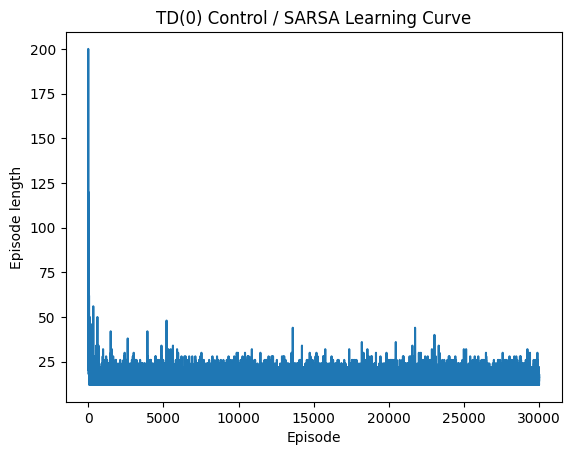

In [45]:
plt.plot(sarsa_lengths)
plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("TD(0) Control / SARSA Learning Curve")
plt.show()

In [46]:
def sarsa_lambda_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=1.0,
    epsilon=0.2,
    lam=0.8,
    max_steps=600
):
    Q = defaultdict(lambda: {a: 0.0 for a in actions})
    lengths = []

    for ep in range(num_episodes):
        E = defaultdict(lambda: {a: 0.0 for a in actions})

        state = start
        action = epsilon_greedy_action(Q, state, epsilon)

        steps = 0

        for t in range(max_steps):
            next_state, reward, done = step(state, action)
            steps += 1

            if done:
                target = reward
                delta = target - Q[state][action]
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                target = reward + gamma * Q[next_state][next_action]
                delta = target - Q[state][action]

            E[state][action] += 1.0

            for s in list(E.keys()):
                for a in actions:
                    Q[s][a] += alpha * delta * E[s][a]
                    E[s][a] *= gamma * lam

            if done:
                break

            state = next_state
            action = next_action

        lengths.append(steps)

    return Q, lengths

In [47]:
Q_sarsa_lambda, sarsa_lambda_lengths = sarsa_lambda_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=gamma,
    epsilon=0.2,
    lam=0.8,
    max_steps=600
)

sarsa_lambda_policy = greedy_policy_from_Q(Q_sarsa_lambda)

print_policy(sarsa_lambda_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ←
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↑ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


In [48]:
episode = generate_episode(
    lambda s: sarsa_lambda_policy[s],
    start_state=start,
    max_steps=100
)

print("length:", len(episode))
print("return:", sum(r for _, _, r in episode))

for t, (s, a, r) in enumerate(episode):
    print(t, s, a)

length: 12
return: -11
0 (0, 1) D
1 (1, 1) D
2 (2, 1) R
3 (2, 2) D
4 (3, 2) D
5 (4, 2) R
6 (4, 3) R
7 (4, 4) R
8 (4, 5) D
9 (5, 5) R
10 (5, 6) D
11 (6, 6) R


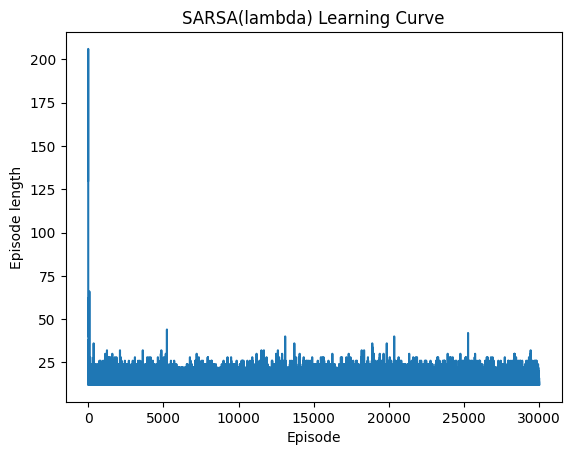

In [49]:
plt.plot(sarsa_lambda_lengths)
plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("SARSA(lambda) Learning Curve")
plt.show()

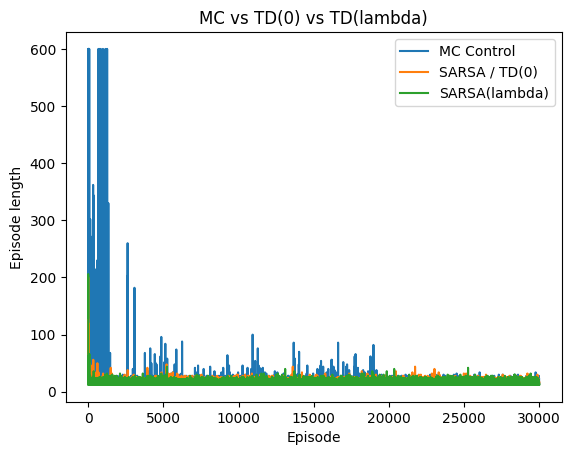

In [50]:
plt.plot(lengths, label="MC Control")
plt.plot(sarsa_lengths, label="SARSA / TD(0)")
plt.plot(sarsa_lambda_lengths, label="SARSA(lambda)")

plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("MC vs TD(0) vs TD(lambda)")
plt.legend()
plt.show()